<a href="https://colab.research.google.com/github/DanZarafusuki/Face-Generation-Using-Pca/blob/main/pca_faces.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading LFW dataset...
Displaying a few original faces...


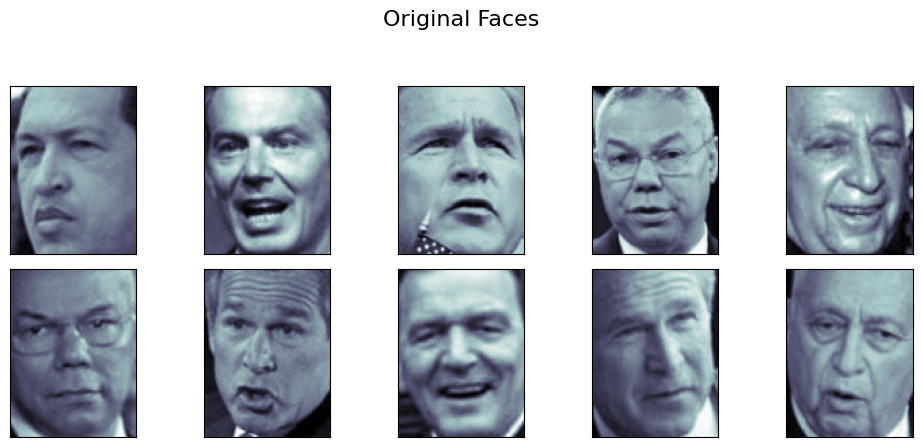

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_lfw_people
from sklearn.decomposition import PCA
import numpy as np

# 1. Load the LFW (Labeled Faces in the Wild) dataset
# We'll use a subset for faster processing
print("Loading LFW dataset...")
lfw_people = fetch_lfw_people(min_faces_per_person=70, resize=1)
n_samples, h, w = lfw_people.images.shape

# For PCA, we need 2D data (samples x features)
X = lfw_people.data
n_features = X.shape[1]

# Plot a few original faces
def plot_faces(images, title, n_row=2, n_col=5, cmap=plt.cm.bone):
    plt.figure(figsize=(2. * n_col, 2.26 * n_row))
    plt.suptitle(title, size=16)
    for i in range(n_row * n_col):
        plt.subplot(n_row, n_col, i + 1)
        plt.imshow(images[i].reshape((h, w)), cmap=cmap)
        plt.xticks(())
        plt.yticks(())
    plt.tight_layout(rect=[0, 0, 1, 0.92])

print("Displaying a few original faces...")
plot_faces(lfw_people.images, "Original Faces")
plt.show()



Converting a sample grayscale face to true black and white...


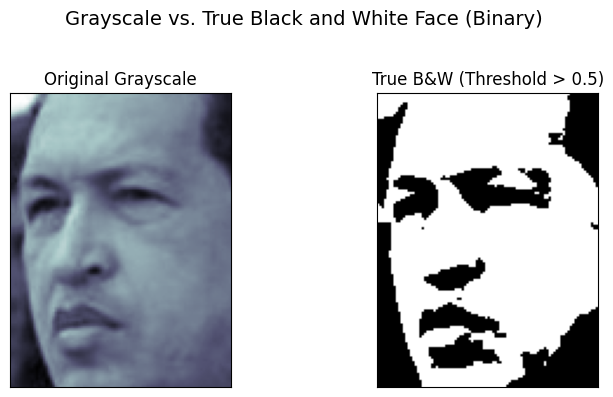

To apply this to the entire dataset for PCA, you would perform this thresholding step on the 'X' data before fitting the PCA model.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

print("Converting a sample grayscale face to true black and white...")

# Take the first original face from the LFW dataset for demonstration
sample_grayscale_face = lfw_people.images[0]

# Define a threshold. Pixels above this value become white (1), below become black (0).
# A common threshold for 0-1 normalized images is 0.5, or you might calculate a mean.
threshold = 0.5 # You can adjust this value

# Apply the threshold to create a binary image
binary_face = (sample_grayscale_face > threshold).astype(float)

# Display the original grayscale face and the new binary face side-by-side
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
fig.suptitle("Grayscale vs. True Black and White Face (Binary)", size=14)

axes[0].imshow(sample_grayscale_face, cmap=plt.cm.bone)
axes[0].set_title("Original Grayscale")
axes[0].set_xticks(())
axes[0].set_yticks(())

axes[1].imshow(binary_face, cmap=plt.cm.bone) # Use bone colormap to keep black/white appearance
axes[1].set_title(f"True B&W (Threshold > {threshold})")
axes[1].set_xticks(())
axes[1].set_yticks(())

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print("To apply this to the entire dataset for PCA, you would perform this thresholding step on the 'X' data before fitting the PCA model.")

Extracting the top 20 Eigenfaces from 1288 faces...
Displaying Eigenfaces...


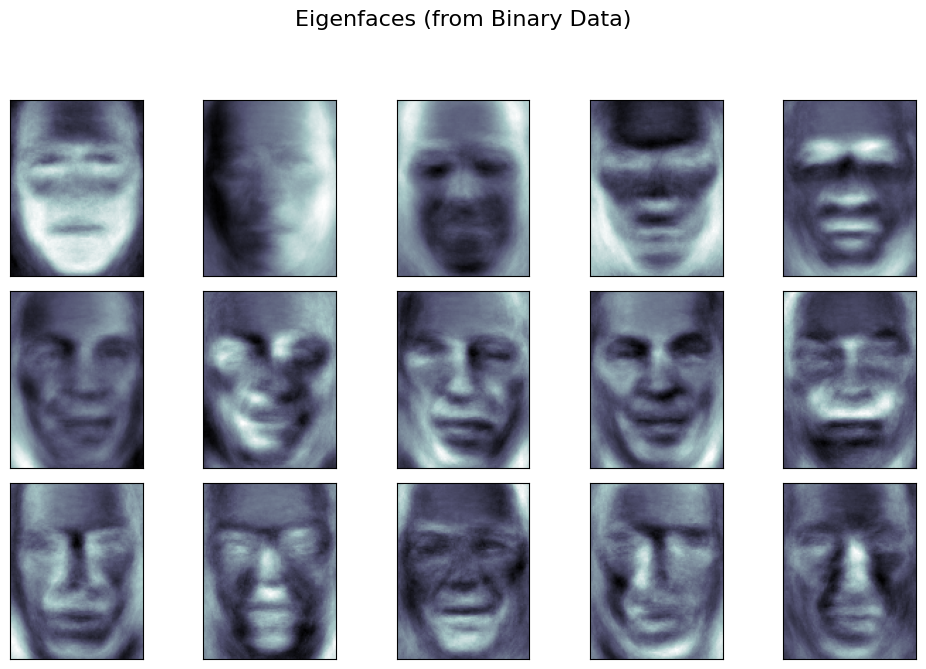

Displaying original (binary) vs. reconstructed (binary) faces...


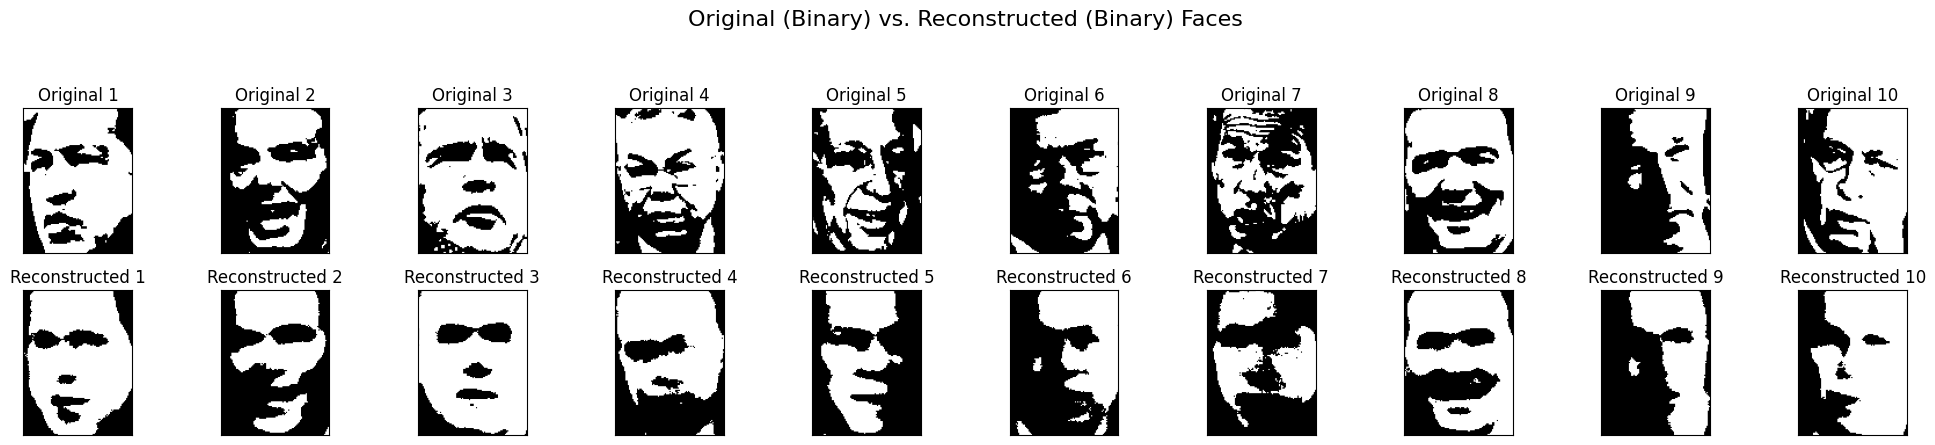


--- Eigenface Generation Complete ---
Dataset size: 1288 samples, each 125x94 pixels.
Number of features (pixels): 11750
Number of PCA components used: 20
The reconstructed faces show how the original (binary) faces can be approximated by a linear combination of Eigenfaces.


In [ ]:
# 2. Apply PCA
# We'll keep enough components to explain a significant portion of the variance
# or a fixed number for visualizing Eigenfaces
n_components = 20 # Number of principal components to keep

# Apply thresholding to the entire dataset X for true black and white
# Using the previously defined threshold (0.5)
X_binary = (X > threshold).astype(float)

print(f"Extracting the top {n_components} Eigenfaces from {n_samples} faces...")
pca = PCA(n_components=n_components, svd_solver='randomized', whiten=True).fit(X_binary)
eigenfaces = pca.components_.reshape((n_components, h, w))

# Plot the Eigenfaces
print("Displaying Eigenfaces...")
plot_faces(eigenfaces, "Eigenfaces (from Binary Data)", n_row=3, n_col=5)
plt.show()

# 3. Create faces using a seed (reconstruction)
# We'll take a few original faces, transform them into the PCA subspace,
# and then project them back to see the reconstruction.

n_reconstruct_faces = 10
original_test_faces_grayscale = lfw_people.images[:n_reconstruct_faces] # Keep original grayscale for reference if needed
original_test_data_binary = X_binary[:n_reconstruct_faces] # Use the binary data for reconstruction

# Transform the faces into the PCA basis (coefficients)
weights = pca.transform(original_test_data_binary)

# Reconstruct faces from the weights (using Eigenfaces)
reconstructed_data = pca.inverse_transform(weights)
reconstructed_faces = reconstructed_data.reshape((n_reconstruct_faces, h, w))

# Re-apply threshold to reconstructed faces to make them strictly black and white for display
reconstructed_faces_binary = (reconstructed_faces > threshold).astype(float)

print("Displaying original (binary) vs. reconstructed (binary) faces...")
fig, axes = plt.subplots(nrows=2, ncols=n_reconstruct_faces, figsize=(2. * n_reconstruct_faces, 4.5))
fig.suptitle("Original (Binary) vs. Reconstructed (Binary) Faces", size=16)

for i in range(n_reconstruct_faces):
    ax = axes[0, i]
    ax.imshow(original_test_data_binary[i].reshape((h, w)), cmap=plt.cm.bone) # Plotting the binary version of original
    ax.set_title(f"Original {i+1}")
    ax.set_xticks(())
    ax.set_yticks(())

    ax = axes[1, i]
    ax.imshow(reconstructed_faces_binary[i], cmap=plt.cm.bone) # Plotting the binary version of reconstructed
    ax.set_title(f"Reconstructed {i+1}")
    ax.set_xticks(())
    ax.set_yticks(())

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

print("\n--- Eigenface Generation Complete ---")
print(f"Dataset size: {n_samples} samples, each {h}x{w} pixels.")
print(f"Number of features (pixels): {n_features}")
print(f"Number of PCA components used: {n_components}")
print("The reconstructed faces show how the original (binary) faces can be approximated by a linear combination of Eigenfaces.")

Generating a new random face...


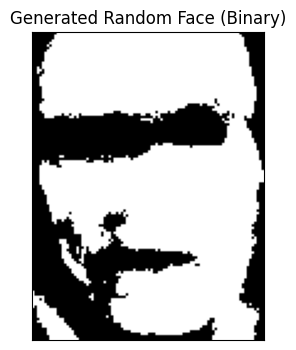

A new random face has been generated.


In [ ]:
print("Generating a new random face...")

# Get the mean and standard deviation of the existing weights to guide random generation
weights_mean = pca.transform(X).mean(axis=0)
weights_std = pca.transform(X).std(axis=0)

# Generate random weights for a new face
# We'll sample from a normal distribution with the mean and std dev of the original weights
random_weights = np.random.normal(loc=weights_mean, scale=weights_std * 0.5) # Scale std to make faces more 'average'

# Reconstruct the random face from these weights
random_face_data = pca.inverse_transform(random_weights)
random_face_image = random_face_data.reshape((h, w))

# Apply threshold to the generated random face to make it strictly black and white
random_face_image_binary = (random_face_image > threshold).astype(float)

# Display the generated random face
plt.figure(figsize=(4, 4))
plt.imshow(random_face_image_binary, cmap=plt.cm.bone)
plt.title("Generated Random Face (Binary)")
plt.xticks(())
plt.yticks(())
plt.show()

print("A new random face has been generated.")

In [ ]:
import numpy as np

print("Exporting raw binary files...")

# Export weights_mean as raw binary
weights_mean.astype(np.float32).tofile('weights_mean.bin')
print("Exported weights_mean to weights_mean.bin")

# Export weights_std as raw binary
weights_std.astype(np.float32).tofile('weights_std.bin')
print("Exported weights_std to weights_std.bin")

# Export principal components (eigenfaces) as raw binary
pca.components_.astype(np.float32).tofile('eigenfaces_components.bin')
print("Exported Eigenfaces (principal components) to eigenfaces_components.bin")

print("You can now download these .bin files from the Colab file browser.")

Exporting raw binary files...
Exported weights_mean to weights_mean.bin
Exported weights_std to weights_std.bin
Exported Eigenfaces (principal components) to eigenfaces_components.bin
You can now download these .bin files from the Colab file browser.


In [ ]:
print("Generating metadata file...")

metadata_content = f"Eigenface Model Metadata:\n"
metadata_content += f"--------------------------\n"
metadata_content += f"Number of Principal Components (n_components): {n_components}\n"
metadata_content += f"Image Height (h): {h}\n"
metadata_content += f"Image Width (w): {w}\n"
metadata_content += f"Total Features (pixels per image): {n_features}\n"
metadata_content += f"Number of Training Samples (n_samples): {n_samples}\n"
metadata_content += f"Binary Threshold for B&W conversion: {threshold}\n"

with open('eigenface_metadata.txt', 'w') as f:
    f.write(metadata_content)

print("Metadata saved to eigenface_metadata.txt")
print("You can now download 'eigenface_metadata.txt' from the Colab file browser.")

Generating metadata file...
Metadata saved to eigenface_metadata.txt
You can now download 'eigenface_metadata.txt' from the Colab file browser.


Loading binary files and generating a face without PCA object...


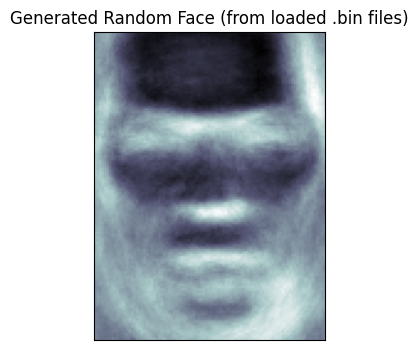

A new random face has been generated from the raw binary files.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

print("Loading binary files and generating a face without PCA object...")

# Assuming n_components, h, w, n_features are already defined in the kernel from previous steps
# If not, they would need to be loaded from the metadata file or hardcoded.
# For this context, we will use the variables already in the kernel state.

# 1. Load the raw binary files back into NumPy arrays
# The .bin files were saved as float32, so load them as such.

# Load weights_mean
loaded_weights_mean = np.fromfile('weights_mean.bin', dtype=np.float32)
# Verify shape, should be (n_components,)
# print(f"Loaded weights_mean shape: {loaded_weights_mean.shape}")

# Load weights_std
loaded_weights_std = np.fromfile('weights_std.bin', dtype=np.float32)
# Verify shape, should be (n_components,)
# print(f"Loaded weights_std shape: {loaded_weights_std.shape}")

# Load eigenfaces_components
loaded_eigenfaces_components = np.fromfile('eigenfaces_components.bin', dtype=np.float32)
# Reshape to (n_components, n_features) based on original dimensions
loaded_eigenfaces_components = loaded_eigenfaces_components.reshape((n_components, n_features))
# Verify shape
# print(f"Loaded eigenfaces_components shape: {loaded_eigenfaces_components.shape}")

# 2. Generate new random weights using the loaded mean and standard deviation
# Apply the same scaling factor (0.5) to the standard deviation for 'average' faces
random_weights_new = np.random.normal(loc=loaded_weights_mean, scale=loaded_weights_std * 0.5)

# 3. Reconstruct the face using the loaded eigenfaces (manual inverse transform)
# Reconstruction: reconstructed_data = np.dot(random_weights, components)
reconstructed_face_data = np.dot(random_weights_new, loaded_eigenfaces_components)

# 4. Reshape the reconstructed data into an image and display
reconstructed_face_image = reconstructed_face_data.reshape((h, w))

plt.figure(figsize=(4, 4))
plt.imshow(reconstructed_face_image, cmap=plt.cm.bone)
plt.title("Generated Random Face (from loaded .bin files)")
plt.xticks(())
plt.yticks(())
plt.show()

print("A new random face has been generated from the raw binary files.")